## PARIS inverse modelling results - notebook edited to produce NIR/NISC style plots

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `m_data` dictionary to point towards the experiment/model you want to plot.

3. Edit the species, start_date and end_date to plot either a timeseries of total fluxes or spatial map of average fluxes.

In [1]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func
import copy
from numpy import isnan

### Path to results directory 
data_dir = '/project/InTEM_GHG/inversion/PARIS_results_sharing/'

### Set ppt_mode to True for bigger fonts
ppt_mode = False

###################################
s_data,m_data,m_colors,annotate_coords = func.initialize_settings(ppt_mode)

species_prior = {'hfc134a':'EDGAR',
                 'hfc143a':'EDGAR',
                 'hfc125':'EDGAR',
                 'hfc32':'EDGAR',
                 'hfc23':'FLAT',
                 'hfc152a':'FLAT',
                 'hfc365mfc':'FLAT',
                 'hfc4310mee':'FLAT',
                 'hfc245fa':'FLAT',
                 'hfc227ea':'FLAT',
                 'pfc218':'FLAT',
                 'pfc318':'FLAT',
                 'pfc116':'EDGARMINVAL',
                 'cf4':'EDGARMINVAL',
                 'cfc11':'FLAT',
                 'cfc12':'FLAT',
                 'hcfc22':'FLAT',
                 'hcfc141b':'FLAT',
                 'hcfc142b':'FLAT',
                 'ccl4':'FLAT',
                 'ch4ccl3':'FLAT',
                 'halon1211':'FLAT',
                 'halon1301':'FLAT',
                 'halon2402':'FLAT',
                 'hfo1234yf':'FLAT',
                 'hfo1234zee':'FLAT',
                 'hfo1233zde':'FLAT'}

species_start_dates = {'hfc134a':'1994-01-01',
                        'hfc143a':'2004-01-01',
                        'hfc125':'1999-01-01',
                        'hfc32':'2004-01-01',
                        'hfc23':'2009-01-01',
                        'hfc152a':'1995-01-01',
                        'hfc365mfc':'2004-01-01',
                        'hfc4310mee':'2011-01-01',
                        'hfc245fa':'2008-01-01',
                        'hfc227ea':'2006-01-01',
                        'pfc218':'2005-01-01',
                        'pfc318':'2011-01-01',
                        'pfc116':'2005-01-01',
                        'cf4':'2005-01-01',
                        'cfc11':'1990-01-01',
                        'cfc12':'1990-01-01',
                        'hfcfc22':'1990-01-01',
                        'hfcfc141b':'1990-01-01',
                        'hfcfc142b':'1990-01-01',
                        'ccl4':'1990-01-01',
                        'ch3ccl3':'1990-01-01',
                        'halon1211':'1995-01-01',
                        'halon1301':'1995-01-01',
                        'halon2402':'1995-01-01',
                        'hfo1234yf':'1990-01-01',
                        'hfo1234zee':'1990-01-01',
                        'hfo1233zde':'1990-01-01'}

m_data = {'intem':                      {'filename':'None',
                                         'label':'InTEM'},  #extra filename only used for total f gas plots
        'intem_NID2025_2year':              {'filename':'InTEM_NAME_EUROPE_NID2025_2year',
                                         'label':'InTEM NID 2025 2 year'},  
        'intem_NID2025':              {'filename':'InTEM_NAME_EUROPE_NID2025',
                                         'label':'InTEM'},
        'intem_NID2025_n2o':              {'filename':'InTEM_NAME_EUROPE_NID2025_3year',
                                         'label':'InTEM 1site'},
        'intem_NID2025_monthly':              {'filename':'InTEM_NAME_EUROPE_NID2025',
                                         'label':'InTEM 1month'},  
        'intem_NIR2024':             {'filename':'InTEM_NAME_EUROPE_NIR2024_2year_inversion_A',
                                         'label':'InTEM NIR 2024'},
        'intem_NIR2024_3year':              {'filename':'InTEM_NAME_EUROPE_NIR2024_3year_inversion_A',
                                         'label':'InTEM NIR 2024 3yr'},
        'intem_NIR2024_monthly':              {'filename':'InTEM_NAME_EUROPE_NIR2024_1month_inversion_B',
                                         'label':'InTEM NIR 2024 monthly'}
        }

/home/h02/aramsden/.conda/envs/all/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes


Attempting to read data from intem_NID2025
Reading data from: /project/InTEM_GHG/inversion/PARIS_results_sharing/InTEM/hfc134a/InTEM_NAME_EUROPE_NID2025_hfc134a_yearly.nc
Done!

Masking data from intem_NID2025
Scaling intem_NID2025 country fluxes by 1300000000000.0

Applying rolling means {'intem_NID2025': 3}.


Applying resampling: {'intem_NID2025': None}.

NOTE: If all the data is not within axis limits, adjust the set_ylim parameter


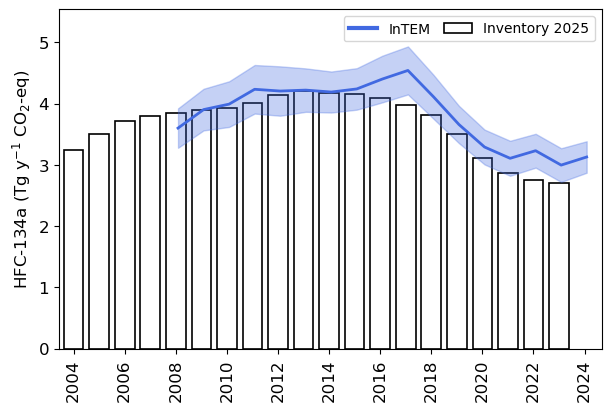

In [5]:
###################################
### edit variables in this block
#species_all = ['hfc134a','hfc143a','hfc125','hfc32','hfc23','hfc152a','hfc365mfc']
#species_all = ['hfc4310mee','hfc245fa','hfc227ea','pfc218','pfc318','pfc116','cf4','nf3]
#species_all = ['all_hfc','all_pfc']
#species_all = ['ch4','n2o','sf6']
species_all = ['hfc134a']

save = False
###################################

for species in species_all:
    
    output_path = f'/home/h02/aramsden/InTEM_GHG_local_files/plots/NID2025/final_plots_NID_2025/{species}_country_flux_UK.png'
    
    regions = ['UK']
    scale_co2eq = True
    
    if any(name in species for name in ['hfc','pfc','cf','hfo','ccl','halon']):   #catches all hfc, pfc, hfo, cfc, hcfc and CCl species
        period_override = None
        if 'all' in species:
            models = ['intem']
            #s_data,m_data,m_colors,annotate_coords = func.initialize_settings(ppt_mode)
            start_date = '2005-01-01'
            end_date = '2025-01-01'
            inventory_start_date = '2005-01-01'
        else:
            models = ['intem_NID2025']
            #start_date = [species_start_dates[species]]
            start_date = ['2008-01-01']    #hfc23 zoom
            end_date = ['2025-01-01']
            #inventory_start_date = '1990-01-01'
            inventory_start_date = '2004-01-01' #hfc23 zoom
            
    elif species == 'ch4':
        models = [f'intem_NID2025_monthly',f'intem_NID2025']
        period_override = ['monthly','yearly']
        start_date = ['2007-01-01','1990-01-01']
        #start_date = ['2006-01-01','2006-01-01'] #shortrun
        end_date = ['2025-01-01','2025-01-01']
        inventory_start_date = '1990-01-01' 
        #inventory_start_date = '2006-01-01' #shortrun
        
    elif species == 'n2o':
        models = [f'intem_NID2025_monthly']#,f'intem_NID2025_n2o']
        period_override = ['monthly']#,'yearly']
        #start_date = ['2012-01-01','1990-01-01']    
        start_date = ['2012-01-01']#,'1990-01-01'] #shortrun
        end_date = ['2025-01-01']#,'2025-01-01']
        #inventory_start_date = '1990-01-01'
        inventory_start_date = '2012-01-01' #shortrun
        
    elif species == 'sf6':
        models = ['intem_NID2025']
        period_override = ['yearly']
        start_date = ['2012-01-01']
        end_date = ['2025-01-01']
        #inventory_start_date = '1990-01-01'
        inventory_start_date = '2006-01-01' #shortrun
        
    elif species == 'nf3':
        models = ['intem_NID2025']
        period_override = ['yearly']
        start_date = ['1990-01-01']
        end_date = ['2025-01-01']
        inventory_start_date = '2012-01-01'
        
    ###################################
    # update priors in filesnames, based on the species and the species_prior dictionary above
    m_data_updated = copy.deepcopy(m_data)
    if 'hfc' in species or 'pfc' in species:        
        if 'all' not in species:
            for k in m_data.keys():
                m_data_updated[k]['filename'] = m_data[k]['filename'].replace('*',species_prior[species])
                
    if type(start_date) == 'str':
        start_date = [start_date]*len(models)
        end_date = [end_date]*len(models)
    ###################################

    ds_all_flux_scaled = {}

    if 'all' in species:
        
        ds_all_flux_scaled = func.read_flux_total_fgases(data_dir,species,models,s_data,m_data_updated,
                                                        regions,start_date,end_date,
                                                        period_override=period_override)
        
        #ds_all_flux_scaled[models[0].split('_')[0]] = ds_all_flux_scaled_read[models[0]]
        
    else:
        ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data_updated,period_override=period_override)

        for i,m in enumerate(models):
            ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date[i],end_date[i],s_data,scale_units=True,
                                                    scale_co2eq=scale_co2eq,species=species)[m]

    model_colors = func.set_model_colors_2(models,m_colors)
    
    ###################################
    ### edit variables in this block
    ### use set rolling_mean to [3] for 1-year to 3-year averaging
    ### or set resample to ['year'] for monthly to yearly averaging
    plot_inventory = True
    inventory_years = ['2025'] #If None, plots most recent. Or can choose list of years: ['2022','2023']. Uncertainties only plotted for most recent year.
    fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                        #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
    plot_prior = [False] #if True, plots prior mean as a dashed line for all models, if list of [True,False] only plots prior for selected models
    add_prior_unc = False #if True: plots prior uncertainty as shaded area
    set_global_leg = False #If True, plots one single legend instead of one legend per subplot.
    country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
    skip_country_title = True
    plot_separate = True #If True, includes all model results as separate lines
    plot_combined = False #If True, combined results, averaged from all models
    resample = [None] #List of values, one for each model. If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
    resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation
    plot_resample_and_original = False #If True, plots both the resampled and original data
    period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
    plot_grid = False #If True, includes background light grey gridlines
    nir_style_plot = True
    rolling_mean = [3]#,None] #If None, does not average results. If set to a number or a list of numbers, a rolling mean will be applied over this many periods (e.g. 3)
    ###################################

    fig = func.plot_country_flux(ds_all_flux_scaled,species,regions,
                                s_data,m_data,model_colors,start_date,end_date,ppt_mode,scale_co2eq,
                                plot_inventory,inventory_years,data_dir,fix_y_axes,plot_prior,
                                add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                                skip_country_title=skip_country_title,
                                plot_separate=plot_separate,plot_combined=plot_combined,
                                resample=resample,resample_uncert_correlation=resample_uncert_correlation,
                                plot_resample_and_original=plot_resample_and_original,
                                period_override=period_override,
                                plot_grid=plot_grid,inventory_start_date=inventory_start_date,
                                nir_style_plot=nir_style_plot,rolling_mean=rolling_mean)

    if save == True:
        fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)
        print(f'\nPlot saved to {output_path}')

### 2. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:


Attempting to read data from intem_NID2025
Reading data from: /project/InTEM_GHG/inversion/PARIS_results_sharing/InTEM/hfc23/InTEM_NAME_EUROPE_NID2025_hfc23_yearly.nc
Done!

Attempting to read data from intem_NID2025
Reading data from: /project/InTEM_GHG/inversion/PARIS_results_sharing/InTEM/hfc23/InTEM_NAME_EUROPE_NID2025_hfc23_yearly_concentrations.nc
Done!

Masking data from intem_NID2025
Scaling intem_NID2025 country fluxes by 1000000.0

Masking data from intem_NID2025
Scaling intem_NID2025 units by 1e-12
Masking sea areas...

Plotting markers for: ['london', 'cardiff', 'edinburgh', 'belfast', 'dublin', 'manchester', 'birmingham']
Edit lines below line 3145 to change marker colour and size
Saved to: /home/h02/aramsden/InTEM_GHG_local_files/plots/NID2025/final_plots_NID_2025/hfc23_posterior_map_UK.png


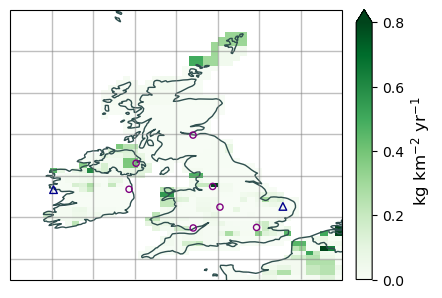

In [3]:
###################################
### edit variables in this block
#species_all = ['hfc134a','hfc143a','hfc125','hfc32','hfc23',
#               'hfc152a','hfc365mfc','hfc4310mee','hfc245fa','hfc227ea',
#             'pfc218','pfc318','pfc116','cf4','nf3','sf6','ch4','n2o']
species_all = ['hfc23']

start_date = '2021-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2025-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year

save = True
###################################

for species in species_all:

    if any(name in species for name in ['hfc','pfc','cf','hfo','ccl','halon']):   #catches all hfc, pfc, hfo, cfc, hcfc and CCl species
        #models = [f'intem_species_1yr']
        models = [f'intem_NID2025']
        period_override = ['yearly']
        season_all = [None]
        outnames = ['']
        mask_sea_areas = True
    elif species == 'ch4':
        models = [f'intem_NID2025']
        period_override = ['monthly']
        season_all = ['DJF','MAM','JJA','SON']
        outnames = ['_winter','_spring','_summer','_autumn']
        mask_sea_areas = False
    elif species == 'n2o':
        models = [f'intem_NID2025_monthly']
        period_override = ['monthly']
        season_all = ['DJF','MAM','JJA','SON']
        outnames = ['_winter','_spring','_summer','_autumn']
        mask_sea_areas = False
    elif species == 'sf6':
        models = ['intem_NID2025']
        period_override = ['yearly']
        season_all = [None]
        outnames = ['']
        mask_sea_areas = True
    elif species == 'nf3':
        models = ['intem_NID2025']
        period_override = ['yearly']
        season_all = [None]
        outnames = ['']
        mask_sea_areas = True
        
    ###################################
        
    # used to update priors in filesnames, based on the species and the species_prior dictionary above
    m_data_updated = copy.deepcopy(m_data)
    if 'hfc' in species or 'pfc' in species:
        for k in m_data.keys():
            m_data_updated[k]['filename'] = m_data[k]['filename'].replace('*',species_prior[species])
            
    ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data,period_override=period_override)

    # tseries file read in used to find sites with data in this period, for accurate site location plotting
    ds_all_mf = func.read_mf(data_dir,species,models,s_data,m_data,period_override=period_override)

    ds_all_flux_scaled = {}
    ds_all_mf_sliced = {}
    
    for m in models:
        ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,s_data,scale_units=True,
                                                scale_co2eq=False,species=species)[m]
        ds_all_mf_sliced[m] = func.slice_mf({m:ds_all_mf[m]},s_data,start_date,end_date,site=None,baseline_site=None,
                                            data_dir=data_dir,scale_units=True,species=species)[m]

    model_colors = func.set_model_colors_2(models,m_colors)
    
    ###################################
    
    sites_available = {}
    for m in models:
        sites_available[m] = []
        for s in range(ds_all_mf_sliced[m].nsite.values.shape[0]):
            if all(isnan(ds_all_mf_sliced[m]['Yobs'].values[:,s])) is False: 
                sites_available[m].append(ds_all_mf_sliced[m]['sitenames'].values[s])
    
    ###################################
    ### edit variables in this block
    plot_area = 'UK'       #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
    cmap = 'Greens'         #flux colour (e.g. 'viridis', 'coolwarm') #use 'green', 'blue' or 'greyscale' to replicate NISC plots
    cmap_diff = 'coolwarm'
    c_border = 'darkslategrey' #country boundary colour (e.g. 'floralwhite', 'dimgrey')
    var = 'flux_total_posterior'  #variable to be plotted. Options for: 'flux_total_posterior', 'flux_total_prior'
    plot_site_locations = True    #If True, adds markers to plots at locations of obs sites
    plot_point_markers = ['london','cardiff','edinburgh','belfast','dublin','manchester','birmingham'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
    plot_inversion_grid_flux = True #If True, plots fluxes at resolution of inversion, if False, plots at the resolution of the prior
    scale_to_kgkm2yr = True #If True, outputs fluxes in kg/km2/year. If False, uses mol/m2/s.
    nir_style_plot = True #If True, adds NIR-style formatting, e.g. adjusts scales, uses different symbols for point_source_markers etc.
    include_threshold = False #If True, sets a minimum plotting value, using values set in the first cell of this notebook.
    ###################################

    for i,season in enumerate(season_all):
        
        output_path = f'/home/h02/aramsden/InTEM_GHG_local_files/plots/NID2025/final_plots_NID_2025/{species}_posterior_map{outnames[i]}_UK.png'
        
        fig = func.plot_spatial_flux_one_variable(ds_all=ds_all_flux_scaled,species=species,plot_area=plot_area,
                                                  s_data=s_data,m_data=m_data,var=var,
                                                  cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                                  period_override=period_override,plot_site_locations=plot_site_locations,
                                                  plot_point_markers=plot_point_markers,season=season,
                                                  plot_inversion_grid_flux=plot_inversion_grid_flux,
                                                  scale_to_kgkm2yr=scale_to_kgkm2yr,
                                                  nir_style_plot=nir_style_plot,mask_sea_areas=mask_sea_areas,
                                                  include_threshold=include_threshold,sites_available=sites_available)

        if save == True:
            fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)
            print(f'Saved to: {output_path}')

##### Prior and posterior fluxes for all models:

In [ ]:
###################################
### edit variables in this block
plot_area = 'UK' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'Greens'   #Greens
cmap_diff = 'coolwarm'
c_border = 'dimgrey'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
season = None #If specified plot the seasonal mean (only valable for monthly data). Options for 'DJF', 'MAM', 'JJA' and 'SON'
plot_inversion_grid_flux = True #If True, plots fluxes at resolution of inversion, if False, plots at the resolution of the prior
NISC_plot = True
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,s_data,m_data,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers,
                             season=season,plot_inversion_grid_flux=plot_inversion_grid_flux)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,s_data,m_data,ppt_mode,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers,
                                        season=season,
                                        plot_inversion_grid_flux=plot_inversion_grid_flux)

### 3. Modelled and observed mole fractions and/or baselines - this has not been edited from the original PARIS notebook

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'hfc134a' 
site = 'MHD'
models = ['intem_NID_2025','intem_NIR2024','intem_NID_2025_2year']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2024-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs                - total observed mole fraction
# uYobs_repeatability - observed repeatability mole fraction uncertainty
# uYobs_variability   - observed variability mole fraction uncertainty
# uYmod               - model mole fraction uncertainty
# uYtotal             - total mole fraction uncertainty
# Yapriori            - prior total mole fraction
# Yapost              - posterior total mole fraction
# YaprioriBC          - prior baseline
# YapostBC            - posterior baseline
# Ybias               - posterior bias added to site
# YaprioriOuter       - prior mole fractions only from outer regions
# YapostOuter         - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,s_data,m_data,period_override=period_override)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

model_colors = func.set_model_colors_2(models,m_colors)

#### Plot timestamps with data at each site:

In [ ]:
fig = func.plot_sites_timeseries(ds_all_mf,'Yapost',start_date,end_date,model_colors,m_data)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/sites.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,
                                    model_colors,s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yobs','Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
# - To choose y axis limits set y_lim=[min_value,max_value]
###################################

Save plot:

In [ ]:
output_path = f'/home/h02/aramsden/PARIS_results/plots/2024_11_NISC/nf3_testing/nf3_{site}_Yapost_2018_2023.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,
                                    model_colors,s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_allmodels.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,
                        model_colors,s_data,m_data,annotate_coords,ppt_mode,
                        include=['Yapost'],
                        diff_include=['Yapost'],
                        y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_diff.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites,
                              var='Yapost')

fig = func.plot_stats_mf(pearson,nrmse,species,
                         model_colors,s_data,m_data,
                         start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = '/home/h02/aramsden/results/RHIME_co2/ch4_31sites_fit_to_Yapost_202101.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)